# Closed Itemset Mining
Implement the CHARM algorithm for frequent closed itemset mining (see Algorithm 9.2 in chapter 9). Download the file mushroom.txt for your runs. Each line of the file contains a transaction, i.e., as set of items that occur together. The transactions do not have to be of the same length, but you may assume that each line will be sorted on the items.

Your script should accept the filename and minimum support value from the command line. It should be run as: ScriptName mushroom.txt MINSUP. Here MINSUP is in absolute numbers.

Your script should output all the frequent closed itemsets in the following format:


closed itemset - support

with one itemset and its support per line. It should also print the total number of frequent closed itemsets on the last line of the output.

Run your code on mushroom.txt for two different values of minsup, namely minsup = 5000, and minsup = 3000, and record the output.

In [1]:
import numpy as np
from collections import defaultdict

In [2]:
def closed_itemset(minsup, file_name='/content/mushroom.txt'):
    """Perform CHARM algorithm for frequent closed itemset mining.
    Args:
        - minsup: minimum support threshold (absolute number)
        - file_name: path to the file that contains transactions
    Returns:
        - Prints all the frequent closed itemsets in the following format: closed itemset - support
        - Prints the total number of frequent closed itemsets on the last line of the output
    """

    # Define IT pairs
    class ITPair:
        def __init__(self, itemset=None, tid=None):
            self.itemset = np.array(itemset) if itemset is not None else np.array([])
            self.tid = np.array(tid) if tid is not None else np.array([])

        def __str__(self):
            return f'Itemset: {self.itemset}\nTid: {self.tid}\n'

        def __repr__(self):
            return f'Itemset: {self.itemset}\nTid: {self.tid}\n'

    # Read in the data
    with open(file_name, 'r') as f:
        lines = f.read().splitlines()
        transactions = [np.array(line.split()).astype(int) for line in lines]

    database = defaultdict(list)

    for tid, itemset in enumerate(transactions):
        for item in itemset:
            database[item].append(tid)

    it_pairs = [ITPair([item], database[item]) for item in database.keys()]

    # Initial call
    C = []
    P_initial = [it_pair for it_pair in it_pairs if it_pair.tid.shape[0] >= minsup]

    # Charm Algorithm
    def charm(P, minsup):
        P = sorted(P, key=lambda it_pair: it_pair.tid.shape[0])
        n = len(P)
        removed = []
        for i in range(n):
            if i not in removed:
                P_i = []
                t_i = P[i].tid
                for j in range(i + 1, n):
                    if j not in removed:
                        X_i = P[i].itemset
                        X_j = P[j].itemset
                        t_j = P[j].tid
                        X_ij = np.union1d(X_i, X_j)
                        t_ij = np.intersect1d(t_i, t_j)

                        if t_ij.shape[0] >= minsup:
                            if np.array_equal(t_i, t_j):  # Property 1
                                # Replace X_i with X_ij in P
                                P[i].itemset = X_ij
                                # Replace X_i with X_ij in P_i
                                P_i = [ITPair(np.union1d(p.itemset, X_j), p.tid) for p in P_i]
                                # Remove <X_j, t(X_j)> from P
                                removed.append(j)
                            else:
                                if np.setdiff1d(t_i, t_j).shape[0] == 0:
                                    # Replace X_i with X_ij in P
                                    P[i].itemset = X_ij
                                    # Replace X_i with X_ij in P_i
                                    P_i = [ITPair(np.union1d(p.itemset, X_j), p.tid) for p in P_i]
                                else:
                                    P_i.append(ITPair(X_ij, t_ij))

                if len(P_i) > 0:
                    charm(P_i, minsup)
                exist_z = False
                for z in C:
                    if np.setdiff1d(P[i].itemset, z.itemset).shape[0] == 0 and np.array_equal(z.tid, P[i].tid):
                        exist_z = True
                        break

                if not exist_z:
                    C.append(P[i])

    charm(P_initial, minsup)  # Run the algorithm

    # Print out the result
    print('Frequent closed itemsets:')
    for pair in C:
        itemset_str = ' '.join(map(str, pair.itemset))
        print(f'{itemset_str} - {len(pair.tid)}')
    print(f'Total number of closed itemsets: {len(C)}')

In [3]:
closed_itemset(minsup=3000)

Frequent closed itemsets:
34 85 86 90 116 - 3104
34 85 86 116 - 3130
85 86 116 - 3148
6 85 90 - 3020
6 34 85 86 - 3096
6 34 85 - 3098
6 85 86 - 3102
6 85 - 3152
10 34 36 85 86 90 - 3016
10 34 85 86 90 - 3044
10 34 85 90 - 3052
10 34 36 85 86 - 3190
10 36 85 86 - 3208
10 34 85 86 - 3218
10 34 85 - 3226
10 85 86 - 3236
10 85 - 3244
23 34 36 39 85 86 - 3016
23 34 63 85 86 - 3040
23 34 85 86 90 93 - 3080
23 34 59 85 86 93 - 3040
23 34 36 85 86 93 - 3080
23 34 85 86 93 - 3184
23 34 36 59 85 86 - 3128
23 34 59 85 86 - 3232
23 34 36 85 86 - 3272
23 34 85 86 - 3376
36 52 85 - 3068
34 52 85 86 - 3298
34 52 85 - 3306
52 85 86 - 3316
52 85 - 3516
2 28 34 39 85 86 - 3024
28 34 39 85 86 - 3096
2 28 39 85 - 3216
28 39 85 - 3288
2 28 34 85 86 - 3216
28 34 85 86 - 3328
28 34 85 - 3336
2 28 85 - 3408
28 85 - 3528
3 36 85 - 3016
3 34 85 86 90 - 3416
3 85 90 - 3464
3 34 85 86 - 3602
3 85 86 - 3608
3 85 - 3656
34 36 39 56 85 86 90 - 3312
34 36 39 56 85 86 - 3432
34 36 56 85 86 90 - 3408
34 36 56 85 86 - 3

In [4]:
closed_itemset(minsup=5000)

Frequent closed itemsets:
59 85 - 5176
34 39 85 86 - 5402
39 85 86 - 5420
39 85 - 5612
34 36 85 86 90 - 6272
36 85 90 - 6464
34 36 85 86 - 6602
36 85 86 - 6620
36 85 - 6812
34 85 86 90 - 7288
34 85 90 - 7296
85 90 - 7488
34 85 86 - 7906
34 85 - 7914
85 86 - 7924
85 - 8124
Total number of closed itemsets: 16


# Example in the book

In [5]:
# (1, 2, 3, 4, 5) -> (A, B, C, D, E)

closed_itemset(minsup=3, file_name='/content/test.txt')

Frequent closed itemsets:
1 2 4 5 - 3
1 2 5 - 4
2 4 - 4
2 3 5 - 3
2 3 - 4
2 5 - 5
2 - 6
Total number of closed itemsets: 7


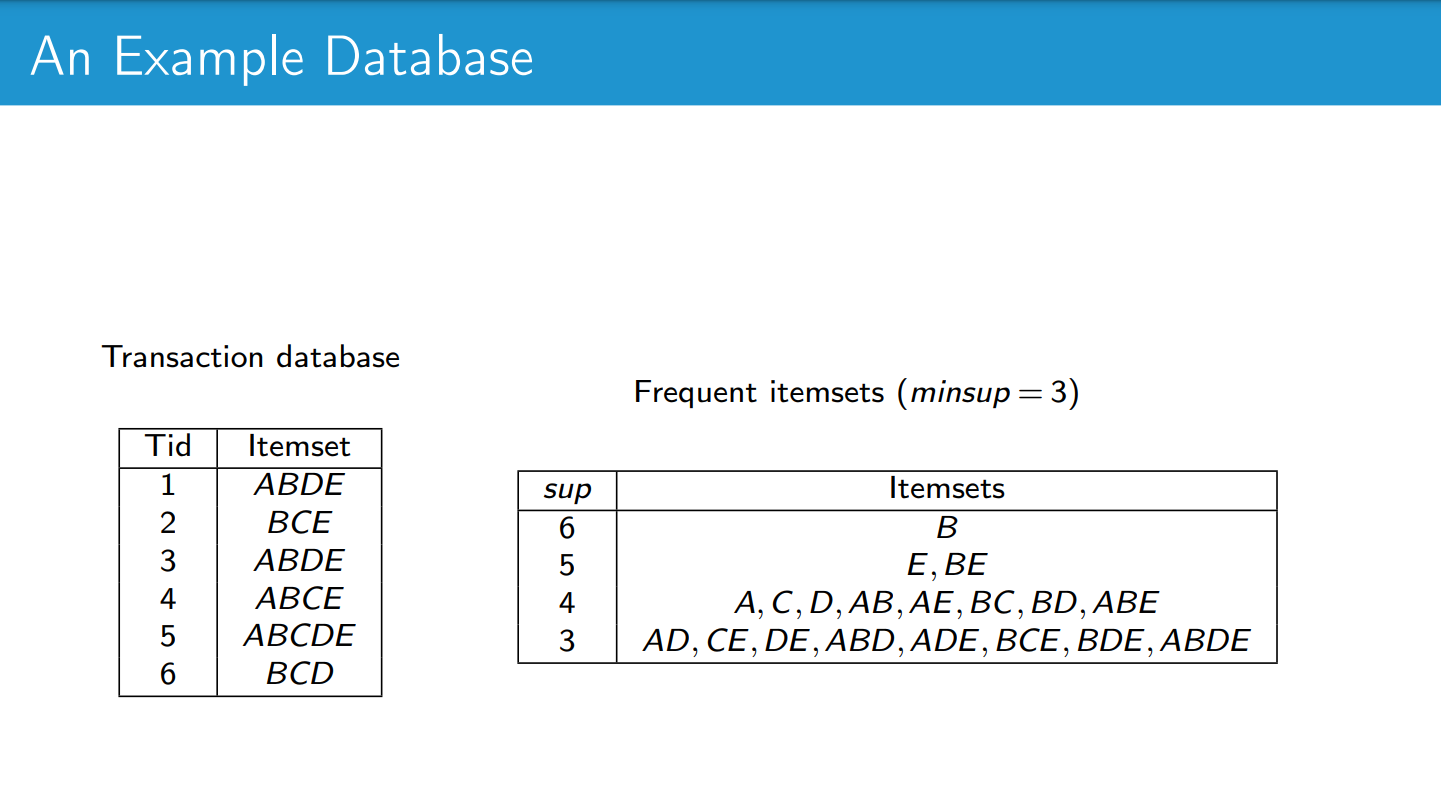